# Analyse des KPI portuaires — opérations navires

Ce notebook se connecte à la base SQLite `db.sqlite3` et calcule notamment :

- le temps d'attente à la bouée de base ;
- la durée de pilotage ;
- le temps passé à quai / durée d'occupation du poste ;
- le temps total passé au port ;
- le taux d'occupation des postes d'accostage ;
- le débit des postes d'accostage ;
- le trafic mensuel et sa variation mensuelle ;
- le temps moyen mensuel passé à la bouée et sa variation mensuelle ;
- des graphiques mensuels.

**Important :** la base fournie ne contient pas de quantité de marchandises/tonnage par escale. Le « trafic » est donc mesuré ici par le **nombre d'escales/navires**. Le débit est exprimé en **escales par jour d'occupation de quai**. Si des données de tonnage/TEU sont ajoutées plus tard, elles pourront remplacer ces proxys.

In [6]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DB_PATH = Path('db.sqlite3')
if not DB_PATH.exists():
    DB_PATH = Path('C:/Users/nicol/OneDrive/Bureau/Projet_PAD/pad_navire/PAD_Project/db.sqlite3')

conn = sqlite3.connect(DB_PATH)
print(f'Base utilisée : {DB_PATH.resolve()}')

Base utilisée : C:\Users\nicol\OneDrive\Bureau\Projet_PAD\pad_navire\PAD_Project\db.sqlite3


## 1. Chargement des données

La table centrale est `escales_escale`. Les tables de référence sont jointes pour obtenir les noms des navires, quais et terminaux.

In [7]:
query = '''
SELECT
    e.id AS escale_id,
    e.date_arrivee,
    e.date_accostage,
    e.date_appareillage,
    e.date_depart,
    e.temps_attente,
    e.temps_sejour,
    e.temps_pilotage,
    e.temps_accostage,
    e.statut,
    e.navire_id,
    n.nom AS navire,
    n.imo,
    n.jauge_brute,
    e.quai_id,
    q.nom AS quai,
    q.longueur AS longueur_quai,
    q.terminal_id,
    t.nom AS terminal,
    tn.libelle AS type_navire
FROM escales_escale e
LEFT JOIN referentiel_navire n ON n.id = e.navire_id
LEFT JOIN referentiel_quai q ON q.id = e.quai_id
LEFT JOIN referentiel_terminal t ON t.id = q.terminal_id
LEFT JOIN referentiel_typenavire tn ON tn.id = n.type_navire_id
'''

df = pd.read_sql_query(query, conn)

date_cols = ['date_arrivee', 'date_accostage', 'date_appareillage', 'date_depart']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f'Nombre d\'escales : {len(df):,}')
display(df.head())

Nombre d'escales : 515


,escale_id,date_arrivee,date_accostage,date_appareillage,date_depart,temps_attente,temps_sejour,temps_pilotage,temps_accostage,statut,navire_id,navire,imo,jauge_brute,quai_id,quai,longueur_quai,terminal_id,terminal,type_navire
0,1,2025-12-28 22:30:00,2025-12-31 03:20:00,2026-01-02 02:52:00,2026-01-02 04:00:00,52.83,101.50,2.60,1.00,terminee,1,MSM DOLORES,9519030,"4,358.00",1,P15,None,1,RTC,BATA
1,2,2025-12-30 15:00:00,2026-01-02 07:18:00,2026-01-11 21:48:00,2026-01-11 23:20:00,64.30,296.33,5.03,2.90,terminee,2,SUNNY FORTUNE,None,"19,887.00",2,P7,None,2,GENERAL CARGO,BULK CARRIER
2,3,2025-12-31 20:30:00,2026-01-02 05:36:00,2026-01-05 05:30:00,2026-01-05 06:24:00,33.10,105.90,3.80,1.90,terminee,3,GRANDE ANGOLA,9343156,"47,128.00",3,P16,None,1,RTC,RORO
3,4,2025-12-28 09:54:00,2025-12-30 02:00:00,2026-01-02 16:36:00,2026-01-02 17:40:00,40.10,127.77,2.83,1.00,terminee,4,MSC HAITI II,9225251,"27,839.00",3,P16,None,1,RTC,PORTE CONTENEURS
4,5,2025-12-04 18:30:00,2025-12-30 15:06:00,2026-01-03 04:06:00,2026-01-03 03:12:00,620.60,704.70,1.40,1.60,terminee,5,COROMEL,9341378,"7,446.00",4,P1,None,3,SCDP,OIL/CHEM TANKER


In [8]:
# Contrôle rapide de qualité des données
quality = pd.DataFrame({
    'Valeurs manquantes': df.isna().sum(),
    'Taux_missing_%': (df.isna().mean() * 100).round(2)
})
display(quality)

print('Statuts :')
display(df['statut'].value_counts(dropna=False).to_frame('nombre'))

,Valeurs manquantes,Taux_missing_%
escale_id,0,0.00
date_arrivee,0,0.00
date_accostage,2,0.39
date_appareillage,13,2.52
date_depart,13,2.52
temps_attente,4,0.78
temps_sejour,16,3.11
temps_pilotage,0,0.00
temps_accostage,2,0.39
statut,0,0.00


Statuts :


,nombre
statut,
terminee,502
en_cours,13


## 2. Construction des indicateurs par escale

### Définitions utilisées

- **Attente à la bouée** : `temps_attente` lorsqu'il est renseigné dans la base. Une valeur calculée à partir des horodatages peut être utilisée en contrôle, mais elle n'est pas substituée automatiquement car la définition métier de `date_arrivee` peut différer de l'arrivée effective à la bouée.
- **Pilotage** : `temps_pilotage` en heures.
- **Temps à quai** : `date_appareillage - date_accostage`.
- **Temps total au port** : `date_depart - date_arrivee`.
- **Temps hors quai jusqu'au départ** : `date_depart - date_appareillage`.

Les valeurs négatives ou incohérentes sont transformées en `NaN` afin de ne pas fausser les KPI.

In [9]:
df['attente_bouee_h'] = pd.to_numeric(df['temps_attente'], errors='coerce')
df['pilotage_h'] = pd.to_numeric(df['temps_pilotage'], errors='coerce')

df['temps_quai_h'] = (
    df['date_appareillage'] - df['date_accostage']
).dt.total_seconds() / 3600

df['temps_total_port_h'] = (
    df['date_depart'] - df['date_arrivee']
).dt.total_seconds() / 3600

df['temps_apres_appareillage_h'] = (
    df['date_depart'] - df['date_appareillage']
).dt.total_seconds() / 3600

for col in ['attente_bouee_h', 'pilotage_h', 'temps_quai_h',
            'temps_total_port_h', 'temps_apres_appareillage_h']:
    df.loc[df[col] < 0, col] = np.nan

# Contrôle des valeurs extrêmes : elles restent conservées, mais sont signalées.
df['alerte_duree'] = (
    (df['attente_bouee_h'] > 24 * 30) |
    (df['temps_quai_h'] > 24 * 30) |
    (df['temps_total_port_h'] > 24 * 60)
)

kpi_escale_cols = [
    'escale_id', 'navire', 'quai', 'terminal', 'date_arrivee',
    'date_accostage', 'date_appareillage', 'date_depart',
    'attente_bouee_h', 'pilotage_h', 'temps_quai_h', 'temps_total_port_h',
    'temps_apres_appareillage_h', 'statut'
]
display(df[kpi_escale_cols].head(10))

,escale_id,navire,quai,terminal,date_arrivee,date_accostage,date_appareillage,date_depart,attente_bouee_h,pilotage_h,temps_quai_h,temps_total_port_h,temps_apres_appareillage_h,statut
0,1,MSM DOLORES,P15,RTC,2025-12-28 22:30:00,2025-12-31 03:20:00,2026-01-02 02:52:00,2026-01-02 04:00:00,52.83,2.60,47.53,101.50,1.13,terminee
1,2,SUNNY FORTUNE,P7,GENERAL CARGO,2025-12-30 15:00:00,2026-01-02 07:18:00,2026-01-11 21:48:00,2026-01-11 23:20:00,64.30,5.03,230.50,296.33,1.53,terminee
2,3,GRANDE ANGOLA,P16,RTC,2025-12-31 20:30:00,2026-01-02 05:36:00,2026-01-05 05:30:00,2026-01-05 06:24:00,33.10,3.80,71.90,105.90,0.90,terminee
3,4,MSC HAITI II,P16,RTC,2025-12-28 09:54:00,2025-12-30 02:00:00,2026-01-02 16:36:00,2026-01-02 17:40:00,40.10,2.83,86.60,127.77,1.07,terminee
4,5,COROMEL,P1,SCDP,2025-12-04 18:30:00,2025-12-30 15:06:00,2026-01-03 04:06:00,2026-01-03 03:12:00,620.60,1.40,85.00,704.70,NaN,terminee
5,6,JIN AN,P5,GENERAL CARGO,2025-12-24 03:30:00,2025-12-24 21:18:00,2026-01-03 03:42:00,2026-01-03 04:36:00,17.80,3.00,222.40,241.10,0.90,terminee
6,7,CMA CGM AGATHA,P15,RTC,2026-01-01 05:48:00,2026-01-02 19:06:00,2026-01-05 06:36:00,2026-01-05 07:48:00,37.30,3.80,59.50,98.00,1.20,terminee
7,8,STAR FIRST,P12,FRUITIER,2026-01-02 15:30:00,2026-01-02 18:28:00,2026-01-04 05:00:00,2026-01-04 05:48:00,2.97,3.32,34.53,38.30,0.80,terminee
8,9,TINA,P16,RTC,2025-12-25 23:30:00,2025-12-26 09:24:00,2026-01-06 18:42:00,2026-01-06 21:12:00,9.90,4.70,273.30,285.70,2.50,terminee
9,10,AFRICAN RUBY,P61,DD,2025-12-12 12:48:00,2026-01-03 05:36:00,2026-01-05 18:48:00,2026-01-05 20:00:00,520.80,3.30,61.20,583.20,1.20,terminee


## 3. KPI globaux de rotation des navires

In [10]:
kpi_global = pd.Series({
    'Nombre d\'escales': df['escale_id'].nunique(),
    'Attente moyenne à la bouée (h)': df['attente_bouee_h'].mean(),
    'Attente médiane à la bouée (h)': df['attente_bouee_h'].median(),
    'Pilotage moyen (h)': df['pilotage_h'].mean(),
    'Temps moyen à quai (h)': df['temps_quai_h'].mean(),
    'Temps moyen au port (h)': df['temps_total_port_h'].mean(),
    'Temps moyen au port (jours)': df['temps_total_port_h'].mean() / 24,
})
display(kpi_global.to_frame('Valeur'))

,Valeur
Nombre d'escales,515.00
Attente moyenne à la bouée (h),92.02
Attente médiane à la bouée (h),29.60
Pilotage moyen (h),69.21
Temps moyen à quai (h),99.77
Temps moyen au port (h),202.64
Temps moyen au port (jours),8.44


## 4. Taux d'occupation mensuel des postes d'accostage

Pour chaque quai et chaque mois, on calcule :

**Taux d'occupation = heures occupées par les navires / heures disponibles du quai × 100**.

La durée d'une escale est découpée aux frontières des mois. Ainsi, une escale qui commence en janvier et se termine en février contribue aux deux mois selon son temps réellement passé à quai.

In [11]:
berth_df = df.dropna(subset=['date_accostage', 'date_appareillage', 'quai']).copy()
berth_df = berth_df[berth_df['date_appareillage'] > berth_df['date_accostage']].copy()

# Liste des mois couverts par les données
min_month = berth_df['date_accostage'].min().to_period('M')
max_month = berth_df['date_appareillage'].max().to_period('M')
months = pd.period_range(min_month, max_month, freq='M')

rows = []
for _, r in berth_df.iterrows():
    start = r['date_accostage']
    end = r['date_appareillage']
    for month in months:
        month_start = month.start_time
        month_end = month.end_time
        overlap_start = max(start, month_start)
        overlap_end = min(end, month_end)
        if overlap_end > overlap_start:
            hours = (overlap_end - overlap_start).total_seconds() / 3600
            rows.append({
                'mois': str(month),
                'quai': r['quai'],
                'escale_id': r['escale_id'],
                'heures_occupees': hours
            })

occupation_detail = pd.DataFrame(rows)

quais = sorted(berth_df['quai'].dropna().unique())
all_month_quai = pd.MultiIndex.from_product(
    [months.astype(str), quais], names=['mois', 'quai']
).to_frame(index=False)

occupation = (
    occupation_detail.groupby(['mois', 'quai'], as_index=False)
    .agg(heures_occupees=('heures_occupees', 'sum'),
         nombre_escales=('escale_id', 'nunique'))
)

occupation = all_month_quai.merge(occupation, on=['mois', 'quai'], how='left')
occupation[['heures_occupees', 'nombre_escales']] = occupation[['heures_occupees', 'nombre_escales']].fillna(0)

occupation['jours_mois'] = pd.PeriodIndex(occupation['mois'], freq='M').days_in_month
occupation['heures_disponibles'] = occupation['jours_mois'] * 24
occupation['taux_occupation_pct'] = (
    occupation['heures_occupees'] / occupation['heures_disponibles'] * 100
)

# Débit : nombre d'escales rapporté aux jours effectivement occupés.
occupation['debit_escales_par_jour_occupe'] = np.where(
    occupation['heures_occupees'] > 0,
    occupation['nombre_escales'] / (occupation['heures_occupees'] / 24),
    np.nan
)

display(occupation.head(20))

,mois,quai,heures_occupees,nombre_escales,jours_mois,heures_disponibles,taux_occupation_pct,debit_escales_par_jour_occupe
0,2025-12,P1,32.90,1.00,31,744,4.42,0.73
1,2025-12,P10,0.00,0.00,31,744,0.00,NaN
2,2025-12,P11,0.00,0.00,31,744,0.00,NaN
3,2025-12,P12,0.00,0.00,31,744,0.00,NaN
4,2025-12,P13,21.00,1.00,31,744,2.82,1.14
5,2025-12,P14,21.00,1.00,31,744,2.82,1.14
6,2025-12,P15,20.67,1.00,31,744,2.78,1.16
7,2025-12,P16,180.60,2.00,31,744,24.27,0.27
8,2025-12,P2,145.40,1.00,31,744,19.54,0.17
9,2025-12,P3,0.00,0.00,31,744,0.00,NaN


### KPI consolidés par mois

Deux lectures sont fournies :
1. le taux d'occupation global de l'ensemble des quais ;
2. le taux d'occupation de chaque poste d'accostage.

In [12]:
occupation_mensuelle = (
    occupation.groupby('mois', as_index=False)
    .agg(
        heures_occupees=('heures_occupees', 'sum'),
        nombre_escales=('nombre_escales', 'sum'),
        nombre_quais=('quai', 'nunique'),
        heures_disponibles_total=('heures_disponibles', 'sum')
    )
)

occupation_mensuelle['taux_occupation_global_pct'] = (
    occupation_mensuelle['heures_occupees'] /
    occupation_mensuelle['heures_disponibles_total'] * 100
)

occupation_mensuelle['debit_escales_par_jour_occupe'] = (
    occupation_mensuelle['nombre_escales'] /
    (occupation_mensuelle['heures_occupees'] / 24)
)

display(occupation_mensuelle)

,mois,heures_occupees,nombre_escales,nombre_quais,heures_disponibles_total,taux_occupation_global_pct,debit_escales_par_jour_occupe
0,2025-12,901.60,12.00,20,14880,6.06,0.32
1,2026-01,"9,312.05",107.00,20,14880,62.58,0.28
2,2026-02,"8,320.87",91.00,20,13440,61.91,0.26
3,2026-03,"9,650.27",108.00,20,14880,64.85,0.27
4,2026-04,"9,216.48",109.00,20,14400,64.00,0.28
5,2026-05,"8,636.17",99.00,20,14880,58.04,0.28
6,2026-06,"3,746.68",52.00,20,14400,26.02,0.33


## 5. Trafic mensuel et variation moyenne

En l'absence de tonnage/TEU dans la base, le trafic est défini comme le **nombre d'escales**. La variation mensuelle est calculée par rapport au mois précédent :

**Variation (%) = (Trafic du mois - Trafic du mois précédent) / Trafic du mois précédent × 100**.

In [13]:
df['mois'] = df['date_arrivee'].dt.to_period('M').astype(str)

trafic_mensuel = (
    df.groupby('mois', as_index=False)
      .agg(trafic_escales=('escale_id', 'nunique'))
)
trafic_mensuel['variation_trafic_pct'] = (
    trafic_mensuel['trafic_escales'].pct_change() * 100
)

display(trafic_mensuel)

,mois,trafic_escales,variation_trafic_pct
0,2025-10,1,NaN
1,2025-11,1,0.00
2,2025-12,20,"1,900.00"
3,2026-01,96,380.00
4,2026-02,78,-18.75
5,2026-03,98,25.64
6,2026-04,86,-12.24
7,2026-05,84,-2.33
8,2026-06,51,-39.29


## 6. Temps moyen à la bouée par mois et variation

La variation mensuelle du temps moyen à la bouée permet d'identifier une dégradation ou une amélioration de la fluidité de l'entrée au port.

In [14]:
bouee_mensuel = (
    df.groupby('mois', as_index=False)
      .agg(
          temps_moyen_bouee_h=('attente_bouee_h', 'mean'),
          temps_median_bouee_h=('attente_bouee_h', 'median'),
          nombre_escales=('escale_id', 'nunique')
      )
)
bouee_mensuel['variation_temps_bouee_pct'] = (
    bouee_mensuel['temps_moyen_bouee_h'].pct_change() * 100
)

display(bouee_mensuel)

,mois,temps_moyen_bouee_h,temps_median_bouee_h,nombre_escales,variation_temps_bouee_pct
0,2025-10,"3,750.10","3,750.10",1,NaN
1,2025-11,"1,153.90","1,153.90",1,-69.23
2,2025-12,225.86,61.30,20,-80.43
3,2026-01,86.41,30.70,96,-61.74
4,2026-02,86.18,30.72,78,-0.26
5,2026-03,96.64,41.10,98,12.13
6,2026-04,64.11,23.35,86,-33.66
7,2026-05,76.54,26.18,84,19.39
8,2026-06,28.65,20.38,51,-62.56


## 7. Tableau mensuel de synthèse

In [15]:
mensuel = trafic_mensuel.merge(bouee_mensuel, on='mois', how='outer')
mensuel = mensuel.merge(
    occupation_mensuelle[['mois', 'taux_occupation_global_pct', 'debit_escales_par_jour_occupe']],
    on='mois', how='outer'
)

mensuel = mensuel.sort_values('mois').reset_index(drop=True)
display(mensuel)

,mois,trafic_escales,variation_trafic_pct,temps_moyen_bouee_h,temps_median_bouee_h,nombre_escales,variation_temps_bouee_pct,taux_occupation_global_pct,debit_escales_par_jour_occupe
0,2025-10,1,NaN,"3,750.10","3,750.10",1,NaN,NaN,NaN
1,2025-11,1,0.00,"1,153.90","1,153.90",1,-69.23,NaN,NaN
2,2025-12,20,"1,900.00",225.86,61.30,20,-80.43,6.06,0.32
3,2026-01,96,380.00,86.41,30.70,96,-61.74,62.58,0.28
4,2026-02,78,-18.75,86.18,30.72,78,-0.26,61.91,0.26
5,2026-03,98,25.64,96.64,41.10,98,12.13,64.85,0.27
6,2026-04,86,-12.24,64.11,23.35,86,-33.66,64.00,0.28
7,2026-05,84,-2.33,76.54,26.18,84,19.39,58.04,0.28
8,2026-06,51,-39.29,28.65,20.38,51,-62.56,26.02,0.33


## 8. Graphique — trafic mensuel et variation

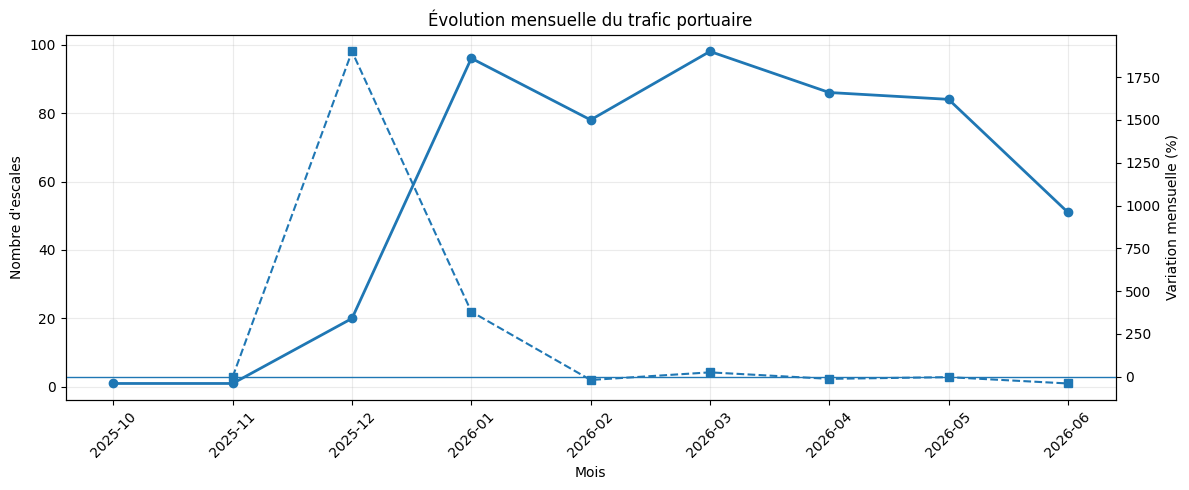

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 5))
x = mensuel['mois']

ax1.plot(x, mensuel['trafic_escales'], marker='o', linewidth=2)
ax1.set_xlabel('Mois')
ax1.set_ylabel('Nombre d\'escales')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(x, mensuel['variation_trafic_pct'], marker='s', linestyle='--')
ax2.axhline(0, linewidth=1)
ax2.set_ylabel('Variation mensuelle (%)')

plt.title('Évolution mensuelle du trafic portuaire')
plt.tight_layout()
plt.show()

## 9. Graphique — temps moyen à la bouée et variation

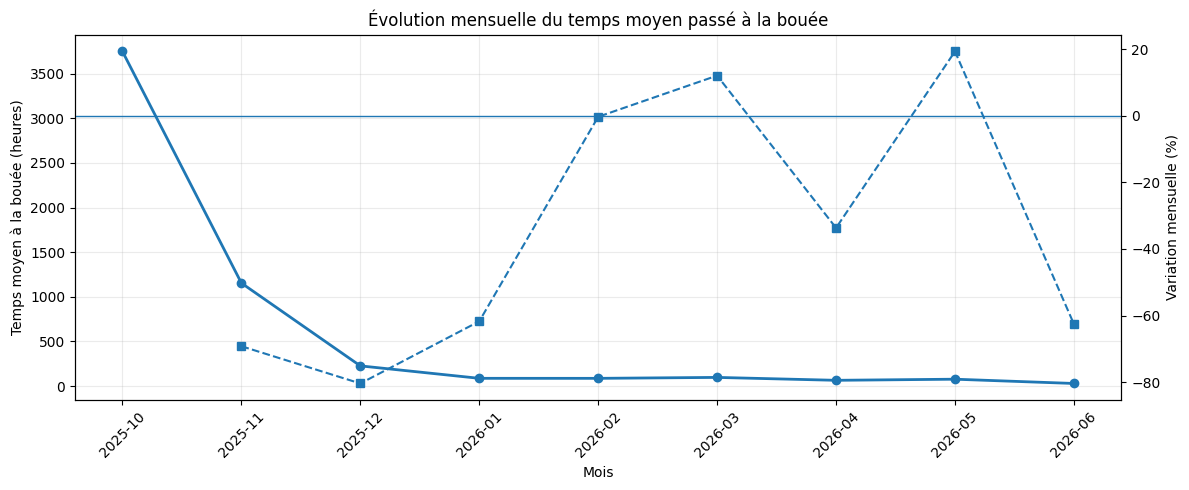

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 5))
x = mensuel['mois']

ax1.plot(x, mensuel['temps_moyen_bouee_h'], marker='o', linewidth=2)
ax1.set_xlabel('Mois')
ax1.set_ylabel('Temps moyen à la bouée (heures)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(x, mensuel['variation_temps_bouee_pct'], marker='s', linestyle='--')
ax2.axhline(0, linewidth=1)
ax2.set_ylabel('Variation mensuelle (%)')

plt.title('Évolution mensuelle du temps moyen passé à la bouée')
plt.tight_layout()
plt.show()

## 10. Graphique — taux d'occupation des postes

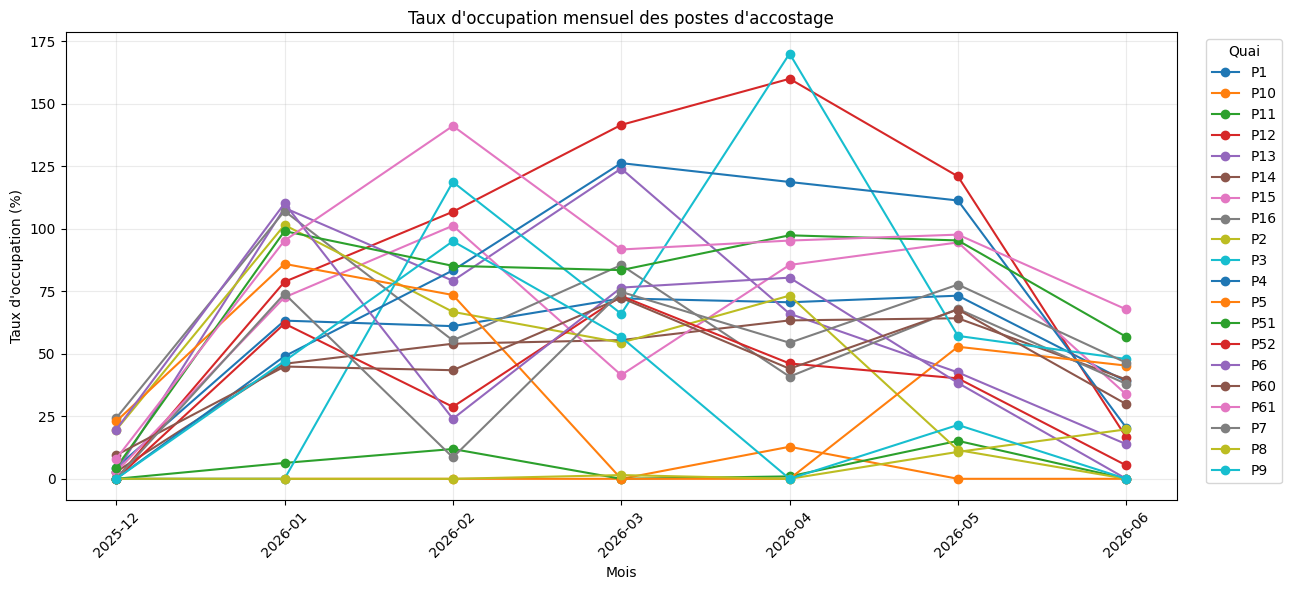

In [18]:
pivot_occupation = occupation.pivot(index='mois', columns='quai', values='taux_occupation_pct')

ax = pivot_occupation.plot(figsize=(13, 6), marker='o')
ax.set_title('Taux d\'occupation mensuel des postes d\'accostage')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux d\'occupation (%)')
ax.grid(True, alpha=0.25)
ax.legend(title='Quai', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Graphique — débit des postes d'accostage

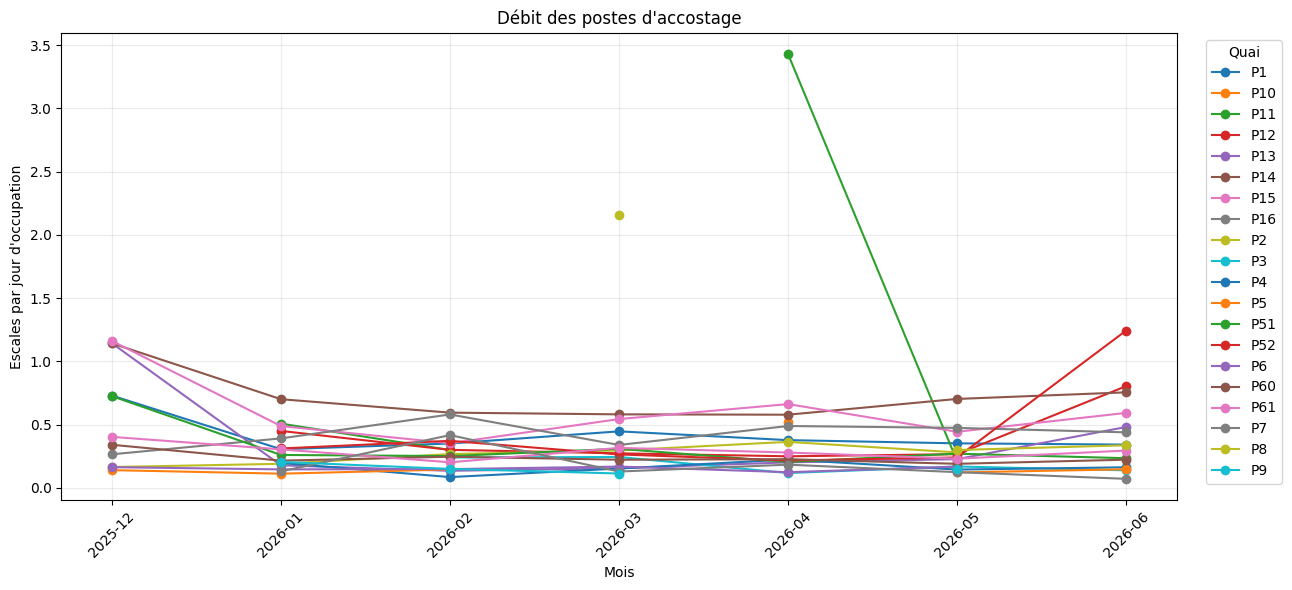

In [19]:
pivot_debit = occupation.pivot(index='mois', columns='quai', values='debit_escales_par_jour_occupe')

ax = pivot_debit.plot(figsize=(13, 6), marker='o')
ax.set_title('Débit des postes d\'accostage')
ax.set_xlabel('Mois')
ax.set_ylabel('Escales par jour d\'occupation')
ax.grid(True, alpha=0.25)
ax.legend(title='Quai', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Analyse des postes d'accostage

Ce tableau permet de repérer les quais les plus sollicités et ceux dont le débit est le plus faible.

In [20]:
analyse_quais = (
    occupation.groupby('quai', as_index=False)
    .agg(
        nombre_escales=('nombre_escales', 'sum'),
        heures_occupees=('heures_occupees', 'sum'),
        taux_occupation_moyen_pct=('taux_occupation_pct', 'mean'),
        debit_moyen_escales_jour=('debit_escales_par_jour_occupe', 'mean')
    )
    .sort_values('taux_occupation_moyen_pct', ascending=False)
)
display(analyse_quais)

,quai,nombre_escales,heures_occupees,taux_occupation_moyen_pct,debit_moyen_escales_jour
3,P12,58.00,"4,528.65",89.25,0.39
16,P61,48.00,"4,300.12",85.27,0.29
12,P51,41.00,"3,783.08",74.53,0.32
10,P4,25.00,"3,694.75",72.74,0.16
9,P3,24.00,"3,283.92",65.70,0.18
4,P13,25.00,"3,174.52",62.42,0.36
6,P15,65.00,"3,111.98",61.70,0.61
7,P16,54.00,"3,058.82",59.86,0.43
0,P1,43.00,"2,784.63",54.82,0.42
14,P6,16.00,"2,560.70",49.87,0.15


## 13. Export des résultats

Les tableaux KPI peuvent être réutilisés dans Power BI, Excel ou une application Django.

In [ ]:
output_dir = Path('exports_kpi')
output_dir.mkdir(exist_ok=True)

df[kpi_escale_cols].to_csv(output_dir / 'kpi_escales.csv', index=False, encoding='utf-8-sig')
mensuel.to_csv(output_dir / 'kpi_mensuels.csv', index=False, encoding='utf-8-sig')
occupation.to_csv(output_dir / 'occupation_quais_mensuelle.csv', index=False, encoding='utf-8-sig')
analyse_quais.to_csv(output_dir / 'analyse_quais.csv', index=False, encoding='utf-8-sig')

print(f'Exports disponibles dans : {output_dir.resolve()}')

Exports disponibles dans : C:\Users\nicol\OneDrive\Bureau\Projet_PAD\pad_navire\PAD_Project\apps\kpi\exports_kpi


: 

## 14. Points d'attention pour une version métier complète

1. **Trafic marchandises** : ajouter une table ou des colonnes de tonnage, TEU, tonnes de vrac, etc. Le trafic pourra alors être exprimé en tonnes/mois ou TEU/mois.
2. **Débit physique des quais** : avec tonnage ou TEU et durée à quai, calculer tonnes/heure ou TEU/heure.
3. **Bouée** : si la base dispose d'un horodatage spécifique d'arrivée à la bouée et de début de pilotage, utiliser ces événements pour un calcul plus précis que `temps_attente`.
4. **Occupation** : le calcul actuel considère le temps entre accostage et appareillage. Pour un KPI d'occupation opérationnelle encore plus précis, il est possible d'intégrer les mouvements de déplacement à l'intérieur du terminal.
5. **Chevauchements** : si deux escales occupent simultanément le même quai, le cumul brut peut dépasser 100 %. Une étape supplémentaire peut être ajoutée pour détecter ces conflits.
6. **Variation moyenne** : le notebook affiche la variation mensuelle. Une moyenne des variations sur toute la période peut être obtenue avec `mensuel['variation_trafic_pct'].mean()` et `mensuel['variation_temps_bouee_pct'].mean()`.